# Reward comparison: old P_diff vs. squareplus

Pulls runs from W&B and plots.
  
Measures:
1. Old P_diff reward vs. squareplus at 0x and 1x noise,
2. Effects of scaling P_diff inside squareplus (1x noise).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, wandb
from pathlib import Path

ENTITY, PROJECT = "models-imperial-college-london8968", "plasmax"
OLD_RUNS = {0: "yzeh8hs6", 1: "h4w85xzn"}  # old P_diff reward, 5.12M steps (from dc_noise_multiplier_results)
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

api = wandb.Api()

def find(d, k):
    if isinstance(d, dict):
        for kk, v in d.items():
            if kk == k:
                return v
            x = find(v, k)
            if x is not None:
                return x

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=200, bbox_inches="tight")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/davidcoope/.netrc.


## 1. Compare P_diff reward vs. squareplus (0x and 1x noise)
- The new reward is `squareplus(P_diff) = (x + sqrt(x^2 + 4)) / 2` per surviving step (x = P_diff in GW). 
- New reward is 1 for a surviving step with P_diff = 0.
- To estimate P_diff for runs using the new reward, we can invert squareplus - this is exact if P_diff were constant; squareplus is convex, so it slightly overestimates the true mean.
- Terminal steps have a reward of `log(squareplus(x))` ≈ 0 rather than ≈ 1 (small effect over ~4400 steps)

In [2]:
SQ_PROJECT = "plasmax-squareplus"
SQ_RUNS = {0: "eie5yotw", 1: "3ari4pty"}  # squareplus reward, 10.24M steps
SEEDS = range(3)
RL = ["evaluation/return_mean", "evaluation/episode_length_mean"]

def history(project, rid, nm, keys):
    r = api.run(f"{ENTITY}/{project}/{rid}")
    assert find(r.config, "noise_multiplier") == nm, (nm, rid)
    return r.history(samples=10000, keys=keys, pandas=True).set_index("_step")

def per_seed(nm):
    h = history(SQ_PROJECT, SQ_RUNS[nm], nm, [f"seeds/{s}/{k}" for s in SEEDS for k in RL])
    d = pd.concat({s: pd.DataFrame({"return": h[f"seeds/{s}/{RL[0]}"], "length": h[f"seeds/{s}/{RL[1]}"]})
                   for s in SEEDS}, names=["seed"])
    d["excess"] = d["return"] - d["length"]
    rbar = d["return"] / d["length"]
    d["P_diff_GW"] = rbar - 1 / rbar  # exact squareplus inverse, assuming constant P_diff
    return d

sq = {nm: per_seed(nm) for nm in SQ_RUNS}
# Old runs only logged seed-averaged metrics; old reward was raw P_diff in GW per step.
old = {nm: history(PROJECT, OLD_RUNS[nm], nm, RL) for nm in SQ_RUNS}
old_pdiff = {nm: h[RL[0]] / h[RL[1]] for nm, h in old.items()}

pd.concat({f"{nm:g}x": d[["length", "excess", "P_diff_GW"]].unstack("seed") for nm, d in sq.items()}, axis=1).round(3)

0x                                                           \
              length                       excess                   P_diff_GW   
seed               0         1         2        0        1        2         0   
_step                                                                           
0.0         3893.797  4309.188  4331.406  167.435  133.223   48.063     0.084   
1024000.0   3622.312  4400.000  4328.297  204.917  183.802   86.722     0.110   
2048000.0   3688.047  4400.000  4400.000  260.698  224.328  136.533     0.137   
3072000.0   3709.000  4400.000  4214.625  234.588   94.859   99.261     0.123   
4096000.0   3813.078  4400.000  3724.078  197.613  -21.224   34.761     0.101   
5120000.0   3595.328  4400.000  4317.750  166.300  -45.924   -1.583     0.090   
6144000.0   4112.047  4400.000  4328.969  146.292  -52.091  -18.351     0.070   
7168000.0   4400.000  4400.000  4400.000   81.213  -52.948  -24.915     0.037   
8192000.0   4263.938  3883.422  4400.000   10.964  -48.613  -24.854     0.005   
9216000.0   4303.578  3755.312  4033.484  -16.089  -47.194  -26.041    -0.007   
10240000.0  4300.953  3433.094  4400.000  -23.030  -42.753  -27.294    -0.011   

                                1x                                        \
                            length                       excess            
seed            1      2         0         1         2        0        1   
_step                                                                      
0.0         0.061  0.022  3661.469  4346.953  4360.562  157.082  134.514   
1024000.0   0.082  0.040  3507.906  4400.000  4399.266  203.820  183.448   
2048000.0   0.099  0.061  3629.406  4400.000  4400.000  259.666  215.422   
3072000.0   0.043  0.047  3604.875  4400.000  4316.031  228.520  100.273   
4096000.0  -0.010  0.019  3972.578  4400.000  3461.844  195.163  -21.637   
5120000.0  -0.021 -0.001  3916.797  4400.000  4284.422  171.885  -44.453   
6144000.0  -0.024 -0.008  4021.297  4400.000  4271.078  143.098  -48.191   
7168000.0  -0.024 -0.011  4367.672  4400.000  4351.375  101.346  -51.160   
8192000.0  -0.025 -0.011  4334.047  4400.000  4331.688   12.797  -53.065   
9216000.0  -0.025 -0.013  4303.844  4400.000  4167.328   -9.633  -53.639   
10240000.0 -0.025 -0.012  4400.000  4400.000  4331.891  -22.636  -53.038   

                                             
                    P_diff_GW                
seed              2         0      1      2  
_step                                        
0.0          48.182     0.084  0.061  0.022  
1024000.0    92.674     0.113  0.082  0.042  
2048000.0   142.936     0.138  0.096  0.064  
3072000.0   112.147     0.123  0.045  0.051  
4096000.0    37.061     0.096 -0.010  0.021  
5120000.0     1.771     0.086 -0.020  0.001  
6144000.0   -18.579     0.070 -0.022 -0.009  
7168000.0   -20.484     0.046 -0.023 -0.009  
8192000.0   -24.179     0.006 -0.024 -0.011  
9216000.0   -24.191    -0.004 -0.025 -0.012  
10240000.0  -28.169    -0.010 -0.024 -0.013

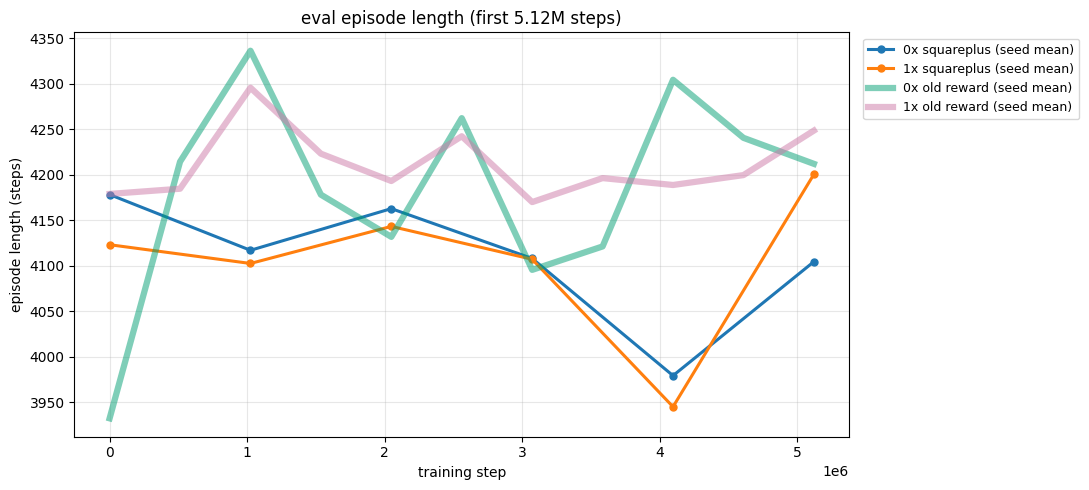

In [3]:
OLD_COLORS = ["#009E73", "#CC79A7"]
T_CROP = 5_120_000  # length plots cropped to the old/scaled runs' length

def seed_lines(ax, col):
    for i, nm in enumerate(SQ_RUNS):
        for s in SEEDS:
            d = sq[nm].xs(s, level="seed")
            ax.plot(d.index, d[col], color=f"C{i}", ls=["-", "--", ":"][s], lw=2.2, marker="o", ms=5,
                    label=f"{nm:g}x squareplus, seed {s}")

def old_lines(ax, series):
    for i, nm in enumerate(SQ_RUNS):
        ax.plot(series[nm].index, series[nm], color=OLD_COLORS[i], lw=4.5, alpha=0.5,
                label=f"{nm:g}x old reward (seed mean)")

def finish(ax, title, ylabel, fname, zero_line=False):
    if zero_line:
        ax.axhline(0, color="k", lw=1)
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.set_xlabel("training step"); ax.grid(alpha=0.3); ax.legend(fontsize=9, loc="upper left", bbox_to_anchor=(1.01, 1))
    ax.figure.tight_layout(); save(ax.figure, fname); plt.show()

def sq_length(nm):
    m = sq[nm]["length"].groupby(level="_step").mean()
    return m[m.index <= T_CROP]

fig, ax = plt.subplots(figsize=(11, 5))
for i, nm in enumerate(SQ_RUNS):
    m = sq_length(nm)
    ax.plot(m.index, m, color=f"C{i}", lw=2.2, marker="o", ms=5, label=f"{nm:g}x squareplus (seed mean)")
old_lines(ax, {nm: h[RL[1]] for nm, h in old.items()})
finish(ax, "eval episode length (first 5.12M steps)", "episode length (steps)", "squareplus_episode_length")

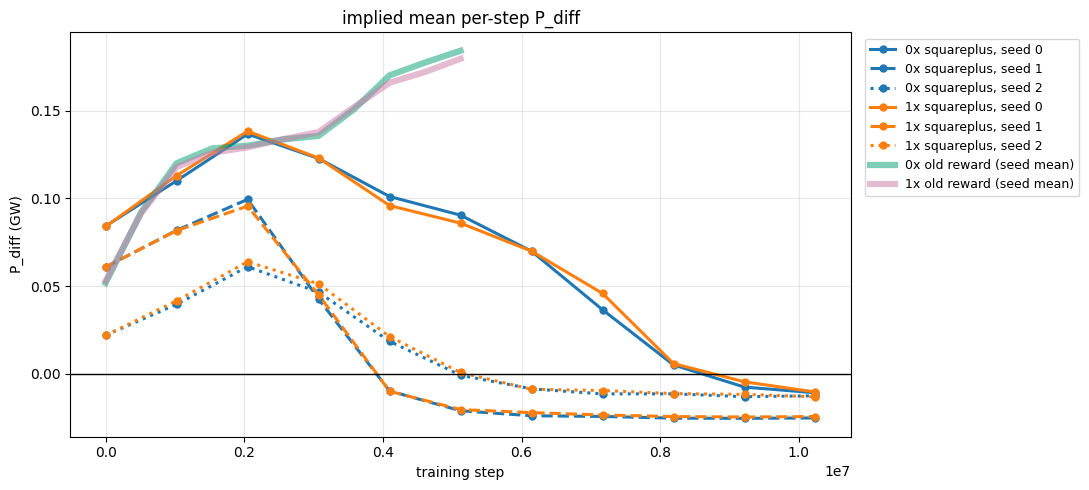

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
seed_lines(ax, "P_diff_GW")
old_lines(ax, old_pdiff)
finish(ax, "implied mean per-step P_diff", "P_diff (GW)", "squareplus_implied_pdiff", zero_line=True)

## 2. Scaling P_diff score inside squareplus (1x noise only)
- Scale the P_diff inside the reward using `--env.reward-score-scale s` which pays `squareplus(s * P_diff)`.
- The implied mean P_diff is `(r - 1/r) / s` with `r = return / length`.
- This is an estimate, not the logged P_diff: exact only if P_diff were constant within the eval rollouts (negligible howerver since convexity bias estimated < ~0.002 GW here). 
- The old-reward line is exact up to terminal steps (old reward was raw P_diff; the disrupting step paid the 0 disruption penalty instead).
- Lines are seed means.

In [5]:
SCALED_RUNS = {5: "lhnv1b8z", 10: "a7eee7ht"}  # squareplus(scale * P_diff), 1x noise, 5.12M steps
SCALED_COLORS = {5: "C3", 10: "C4"}
colors = {1: "C1"} | SCALED_COLORS

def pdiff_run(rid, scale):
    r = api.run(f"{ENTITY}/{SQ_PROJECT}/{rid}")
    assert (find(r.config, "reward_score_scale") or 1.0) == scale, (scale, rid)
    h = history(SQ_PROJECT, rid, 1, [f"seeds/{s}/{k}" for s in SEEDS for k in RL])
    h = h[h.index <= T_CROP]
    rbar = pd.concat({s: h[f"seeds/{s}/{RL[0]}"] / h[f"seeds/{s}/{RL[1]}"] for s in SEEDS}, axis=1)
    return ((rbar - 1 / rbar) / scale).mean(axis=1)  # per-seed inverse, then seed mean

pdiff = {1: pdiff_run(SQ_RUNS[1], 1.0)} | {s: pdiff_run(rid, float(s)) for s, rid in SCALED_RUNS.items()}
old_1x_pdiff = old[1][RL[0]] / old[1][RL[1]]
scaled_len = {scale: history(SQ_PROJECT, rid, 1, RL)[RL[1]] for scale, rid in SCALED_RUNS.items()}

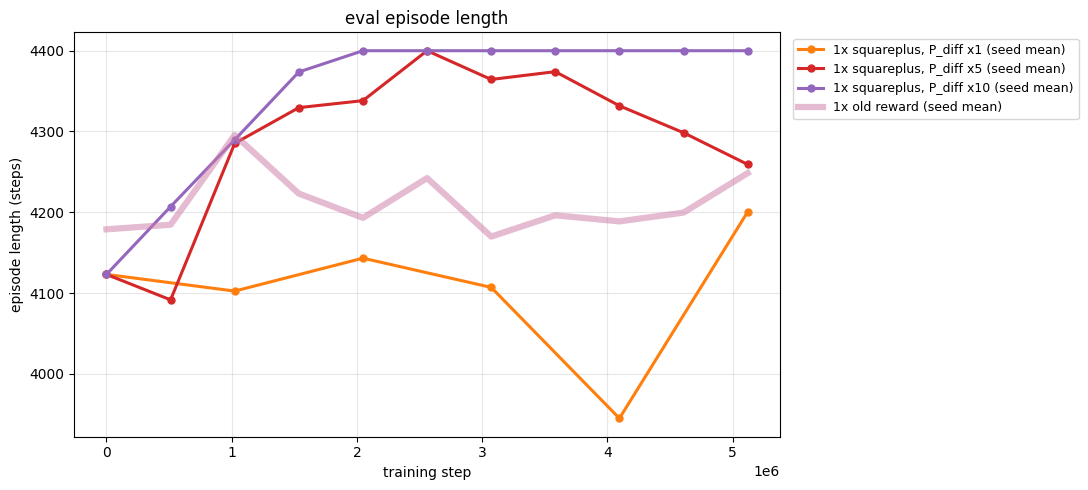

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
m = sq_length(1)
ax.plot(m.index, m, color=colors[1], lw=2.2, marker="o", ms=5, label="1x squareplus, P_diff x1 (seed mean)")
for scale, h in scaled_len.items():
    ax.plot(h.index, h, color=colors[scale], lw=2.2, marker="o", ms=5, label=f"1x squareplus, P_diff x{scale} (seed mean)")
ax.plot(old[1].index, old[1][RL[1]], color=OLD_COLORS[1], lw=4.5, alpha=0.5, label="1x old reward (seed mean)")
finish(ax, "eval episode length", "episode length (steps)", "pdiff_scaling_episode_length")

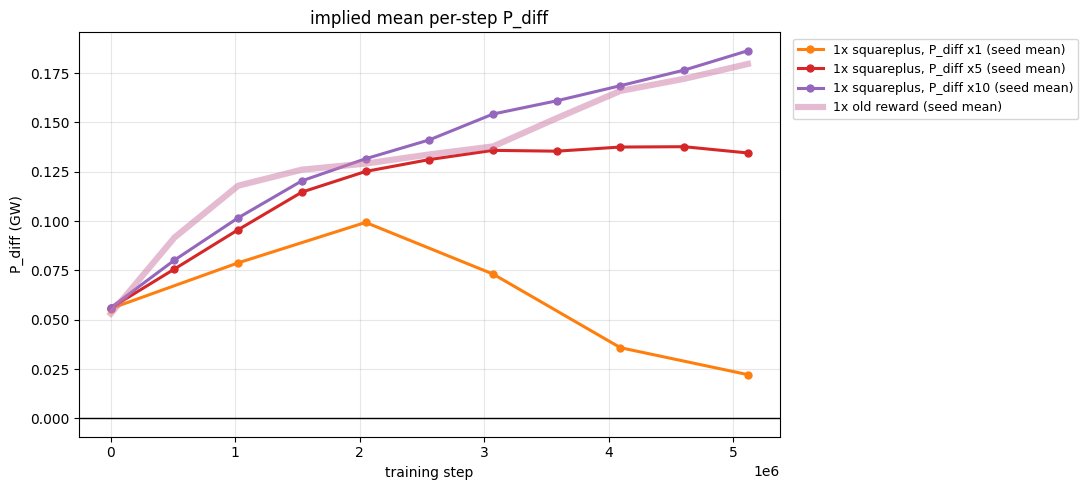

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
for s, m in pdiff.items():
    ax.plot(m.index, m, color=colors[s], lw=2.2, marker="o", ms=5, label=f"1x squareplus, P_diff x{s:g} (seed mean)")
ax.plot(old_1x_pdiff.index, old_1x_pdiff, color=OLD_COLORS[1], lw=4.5, alpha=0.5, label="1x old reward (seed mean)")
finish(ax, "implied mean per-step P_diff", "P_diff (GW)", "pdiff_scaling_implied_pdiff", zero_line=True)